# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [14]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [15]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_value = df.isnull().mean()
print(missing_value)
# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)
print("Các cột còn lại:", list(df.columns))

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'embark_town', 'alone']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Vì `alive` chính là survived cho nên mô hình chỉ cần lấy dữ liệu từ alive để làm output thay vì dự đoán

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [16]:
# TODO 2: shape, info, describe
shape = df.shape
print(shape)
df.info()
print('Các cột số')
display(df.describe())
print('Các cột phân loại')
display(df.describe(include = 'object'))

(891, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   embark_town  889 non-null    object 
 9   alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(3)
memory usage: 63.6+ KB
Các cột số


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Các cột phân loại


,sex,embarked,embark_town
count,891,889,889
unique,2,3,3
top,male,S,Southampton
freq,577,644,644


**Trả lời 2 (biến số vs biến phân loại):**

- Cột biến số là: survived, pclass, age, sibsp, parch, fare
- Cột biến phân loại là: sex, embarked, embark_town

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [17]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100
missing_df = pd.DataFrame({
    'Missing count' : missing_count,
    'Missing percent': missing_percent
})
display(missing_df)

,Missing count,Missing percent
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
embark_town,2,0.224467
alone,0,0.000000


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | 19.865 | Điền median | Vì tỉ lệ thiếu của cột quá lớn nên nếu xoá các phần tử thiếu thì sẽ mất mát một lượng lớn dữ liệu, nếu điền giá trị bất kì thì sẽ ảnh hưởng đến phân phối của cột cho nên lựa chọn điền median là một lựa chọn an toàn hơn vì nó giúp không gây mất mát dữ liệu, dữ liệu cũng sẽ không bị ảnh hưởng đến phân phối dữ liệu và điền median sẽ không chịu ảnh hưỏng của outlier |
| embarked | 0.224 | Xoá | Vì tỉ lệ thiếu rất ít nên ta có thể xoá dữ liệu mà không gây ảnh hưởng quá lớn đến dataset|
| embarked_town | 0.224 | Xoá | Vì tỉ lệ thiếu rất ít nên ta có thể xoá dữ liệu mà không gây ảnh hưởng quá lớn đến dataset|

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [18]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    tren = Q3 + 1.5 * IQR
    duoi = Q1 - 1.5 * IQR
    return ((s > tren) | (s < duoi)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    return (np.abs(stats.zscore(s.dropna()) > nguong)).sum()    # trả về số lượng outlier theo Z-score

for col in ["age", "fare"]:
    print(f'{col} có số điểm outlier là:')
    print(f'IQR: {dem_outlier_iqr(df[col])}')
    print(f'Z-score: {dem_outlier_zscore(df[col])}')
    print('\n')

age có số điểm outlier là:
IQR: 11
Z-score: 2


fare có số điểm outlier là:
IQR: 116
Z-score: 20




**Trả lời 4 (quyết định với outlier của `fare`):**
Nên giữ lại vì các giá trị outlier này có phần trăm rất lớn cho nên đây là vé hạng nhất có giá rất cao so với hạng phổ thông

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

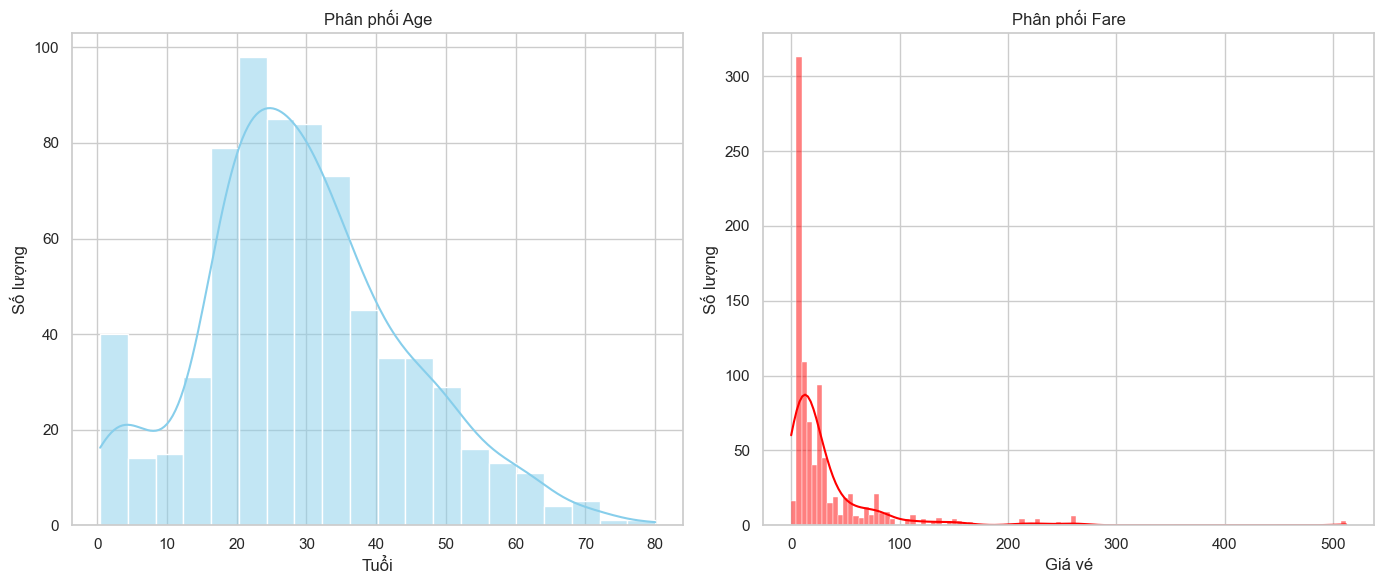

In [20]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

sns.histplot(data = df, x = 'age', kde = True, ax = axes[0], color = 'skyblue')
axes[0].set_title('Phân phối Age')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Số lượng')

sns.histplot(data = df, x = 'fare', kde = True, ax = axes[1], color = 'red')
axes[1].set_title('Phân phối Fare')
axes[1].set_xlabel('Giá vé')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

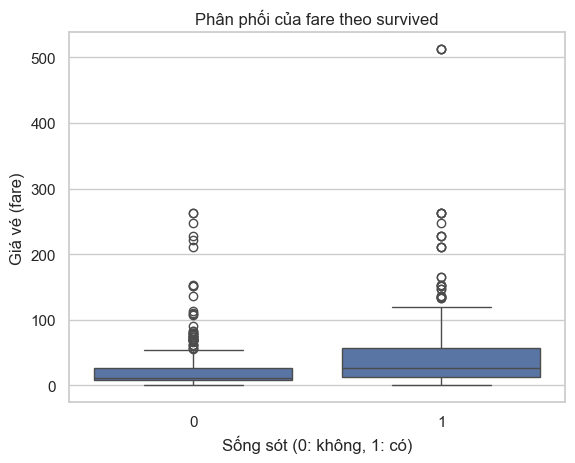

In [22]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
sns.boxplot(data = df, x = 'survived', y = 'fare')
plt.title('Phân phối của fare theo survived')
plt.xlabel('Sống sót (0: không, 1: có)')
plt.ylabel('Giá vé (fare)')
plt.show()

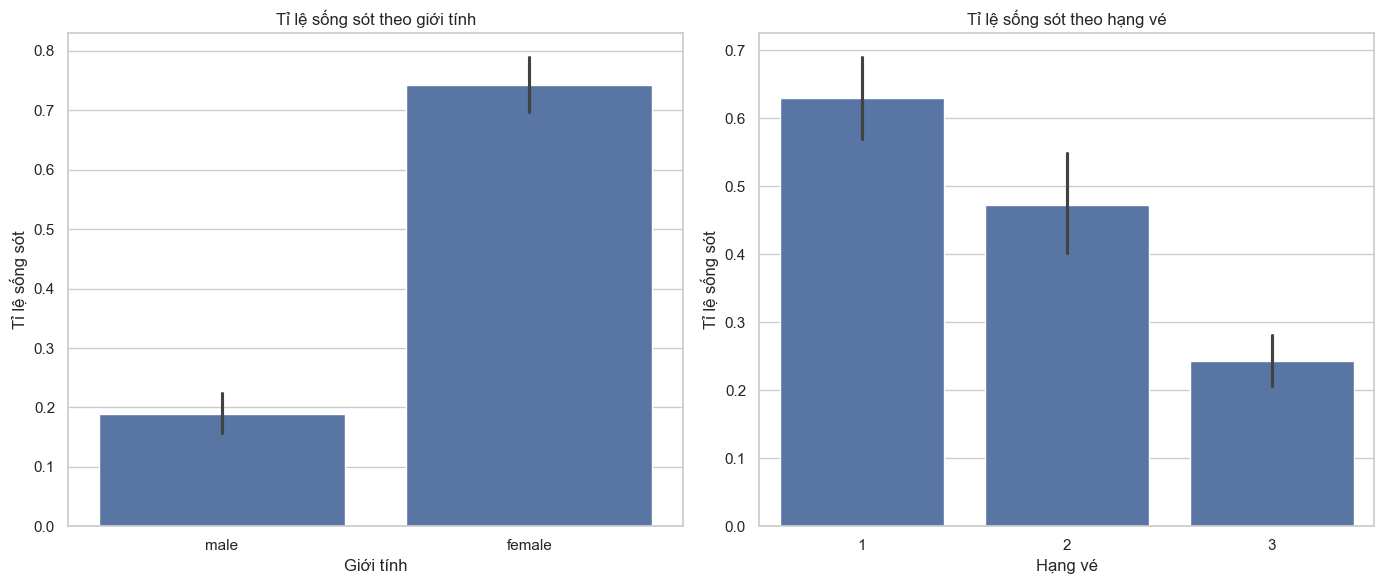

In [25]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize = (14, 6))
sns.barplot(data = df, x = 'sex', y = 'survived', ax = axes[0])
axes[0].set_title('Tỉ lệ sống sót theo giới tính')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Tỉ lệ sống sót')

sns.barplot(data = df, x = 'pclass', y = 'survived', ax = axes[1])
axes[1].set_title('Tỉ lệ sống sót theo hạng vé')
axes[1].set_xlabel('Hạng vé')
axes[1].set_ylabel('Tỉ lệ sống sót')

plt.tight_layout()
plt.show()

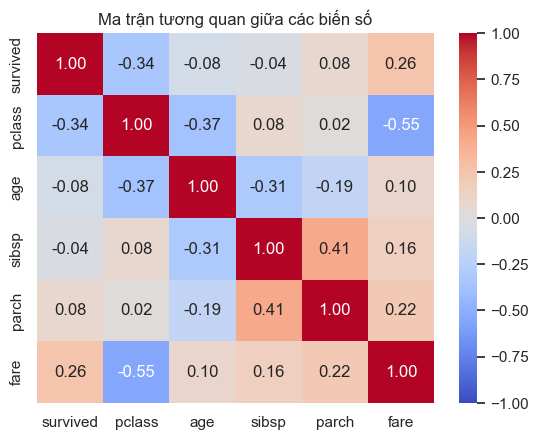

In [28]:
# TODO 5d: Heatmap correlation
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, fmt = '.2f', cmap ='coolwarm', vmin = - 1, vmax = 1)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Phân phối của tuổi bị lệch phải và tập trung chủ yếu ở 20-30 tuổi, phân phối của fare bị lệch phải rất nhiều và giá vé chủ yếu tập trung từ 0-100$
- Boxplot: giá vé có mối liên quan tỉ lệ thuận với việc sống sót, hành khách trả tiền cao hơn thì tỉ lệ sống sót cao hơn
- Bar survival: Phụ nữ sẽ có tỉ lệ sống sót cao hơn đàn ông, hạng vé càng cao thì tỉ lệ sống sót càng cao
- Heatmap: hạng vé (pclass) và giá vé (fare) có tương quan mạnh nhất với khả năng sống sót (survived). Hành khách hạng vé cao hơn và trả nhiều tiền hơn thì tỉ lệ sống cao hơn rõ rệt

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [29]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X,y, test_size= 0.15, random_state=0, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size= 15/85, random_state=0, stratify=y_tmp)

# In shape (kích thước) của 3 tập
print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")

print("-" * 30)

# In tỷ lệ sống sót (mean của y) trong từng tập
print(f"Tỷ lệ Survived (Train): {y_train.mean():.4f}")
print(f"Tỷ lệ Survived (Val):   {y_val.mean():.4f}")
print(f"Tỷ lệ Survived (Test):  {y_test.mean():.4f}")

Train shape: (623, 9)
Val shape:   (134, 9)
Test shape:  (134, 9)
------------------------------
Tỷ lệ Survived (Train): 0.3836
Tỷ lệ Survived (Val):   0.3881
Tỷ lệ Survived (Test):  0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [30]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot",  OneHotEncoder()),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_test_t = preprocess.transform(X_test)
X_val_t = preprocess.transform(X_val)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Vì nếu fit trên test hay val thì nó sẽ biết được các đặt trưng của tập đó dẫn đến overfitting

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [32]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
ty_le = df['survived'].value_counts(normalize=True)*100
print(ty_le)

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến mục tiêu bị mất cân bằng nhẹ vì nhóm không sống sót chiếm 61.62% còn nhóm sống sót chiếm 38.38%
2. Có thể bị lừa trong trường hợp ví dụ bộ dữ liệu có 99% người là không sống sót và 1% là sống sót thì mô hình chỉ cần dự đoán là không sống sót thì Accuracy đạt 99%
3. Ưu tiên cọn F1-score vì nó thể hiện độ hài hoà dữ Recall và Precision, đánh giá thực tế được khả năng của mô hình mà không bị thiên lệch do nhóm dữ liệu đa số

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Biến số có tác động mạnh nhất đến khả năng sống sót là hạng vé (pclass) với hệ số tương quan ở task 5 là -0.34
2. Cột thiếu nhiều nhất là tuổi(age) và cách xử lý là điền median vì giúp bảo toàn số lượng dữ liệu, không ảnh hưởng đến phân phối chung và không ảnh hưởng bởi outlier
3. Biến mục tiêu bị mất cân bằng nhẹ, nên phải chọn F1-score làm metric để đánh giá chính xác khả năng nhận diện của từng tập dữ liệu
4. Scaling áp dụng cho các biến số và encoding cho các biến phân loại vì chỉ có thể fit khi dữ liệu là số, mô hình không thể học từ các dạng chuỗi
5. Có người không trả tiền vẫn có thể đi tàu, ngược lại có những người trả số tiền cực kì lớn. Nhưng toàn bộ khách mua vé tàu với mức giá cao đều sống sót

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [ ]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
